# **Taller 4 - ¿A quién le vendemos?**

Presentado por:
Andrea Correa Magaña, Paula Estefania Guarin Tangarife, Juan Sebastian Calderon Guevara

## Importación librerías

In [ ]:
#Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import textwrap

#Paleta colores azules
AZUL_OSCURO = "#0D47A1"
AZUL_MEDIO  = "#1E88E5"
AZUL_CLARO  = "#90CAF9"
ACENTO      = "#E53935"
PALETA_AZUL = ["#0D47A1", "#1565C0", "#1E88E5", "#42A5F5", "#64B5F6", "#90CAF9", "#BBDEFB"]

sns.set_style("white")
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETA_AZUL),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E3F2FD",
    "grid.linewidth": 0.8,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

def tabla_bonita(df, titulo, cols_pct=None):
    """Convierte un DataFrame en una tabla azul lista para copiar a la pptx."""
    cols_pct = cols_pct or []
    df_fmt = df.copy()
    for c in df_fmt.columns:
        if c in cols_pct:
            df_fmt[c] = df[c].apply(lambda v: f"{v:.1%}")
        elif pd.api.types.is_float_dtype(df[c]):
            df_fmt[c] = df[c].apply(lambda v: f"{v:,.4g}")

    encabezados = ["\n".join(textwrap.wrap(str(c), 16)) for c in df_fmt.columns]

    anchos_chars = []
    for c in df_fmt.columns:
        largo_dato = df_fmt[c].astype(str).str.len().max()
        largo_encabezado = max(len(linea) for linea in str(c).split())
        anchos_chars.append(max(largo_dato, largo_encabezado, 6))
    total = sum(anchos_chars)
    anchos_rel = [a / total for a in anchos_chars]

    ancho_fig = max(2.5 + 1.9 * len(df_fmt.columns), 8)
    alto_fig = 1.0 + 0.55 * len(df_fmt)

    fig, ax = plt.subplots(figsize=(ancho_fig, alto_fig))
    ax.axis('off')
    tabla = ax.table(cellText=df_fmt.values, colLabels=encabezados, colWidths=anchos_rel, cellLoc='center', loc='center')
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(11)
    tabla.scale(1, 2.4)

    for (row, col), celda in tabla.get_celld().items():
        celda.set_edgecolor('white')
        celda.set_linewidth(2)
        if row == 0:
            celda.set_facecolor(AZUL_OSCURO)
            celda.get_text().set_color('white')
            celda.get_text().set_fontweight('bold')
        else:
            celda.set_facecolor('#EAF2FD' if row % 2 == 0 else 'white')
        if col == 0:
            celda.set_text_props(ha='left')
            celda.PAD = 0.03

    plt.title(titulo, fontsize=14, fontweight='bold', pad=18)
    plt.tight_layout()
    plt.show()

## Paso 1.Exploración y el problema de negocio

### Revision inicial de datos

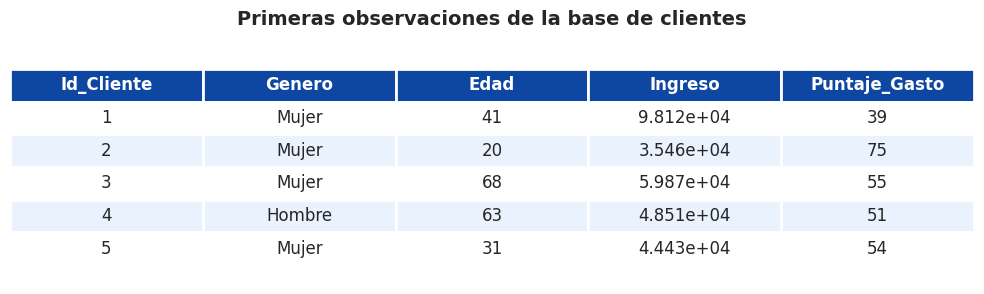

In [ ]:
# Cargar base de datos
df = pd.read_csv("datos_clientes.csv")

# Visualizar primeras observaciones
tabla_bonita(df.head(), "Primeras observaciones de la base de clientes")

In [ ]:
# Dimensión de la base
print(f"Número de clientes: {df.shape[0]}")
print(f"Número de variables: {df.shape[1]}")

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

Número de clientes: 200
Número de variables: 5

Tipos de datos:
Id_Cliente         int64
Genero            object
Edad               int64
Ingreso          float64
Puntaje_Gasto      int64
dtype: object

Valores faltantes:
Id_Cliente       0
Genero           0
Edad             0
Ingreso          0
Puntaje_Gasto    0
dtype: int64


### Estadísticas descriptivas

Se analizan las principales características numéricas de los clientes: edad, ingreso anual y puntaje de gasto.
Estas variables permiten tener una primera aproximación al perfil de los clientes y a la variabilidad existente dentro de la base.

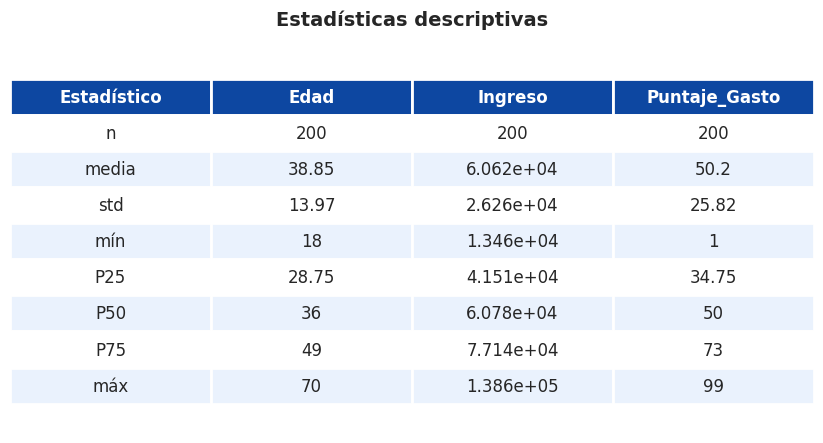

In [ ]:
# Variables numéricas de interés
variables_numericas = [
    "Edad",
    "Ingreso",
    "Puntaje_Gasto"
]
# Estadísticas descriptivas
descriptivas = df[variables_numericas].describe().round(2)

descriptivas.index = [
    "n",
    "media",
    "std",
    "mín",
    "P25",
    "P50",
    "P75",
    "máx"
]

tabla_bonita(descriptivas.reset_index().rename(columns={"index": "Estadístico"}), "Estadísticas descriptivas")

### Distribución de las variables numéricas

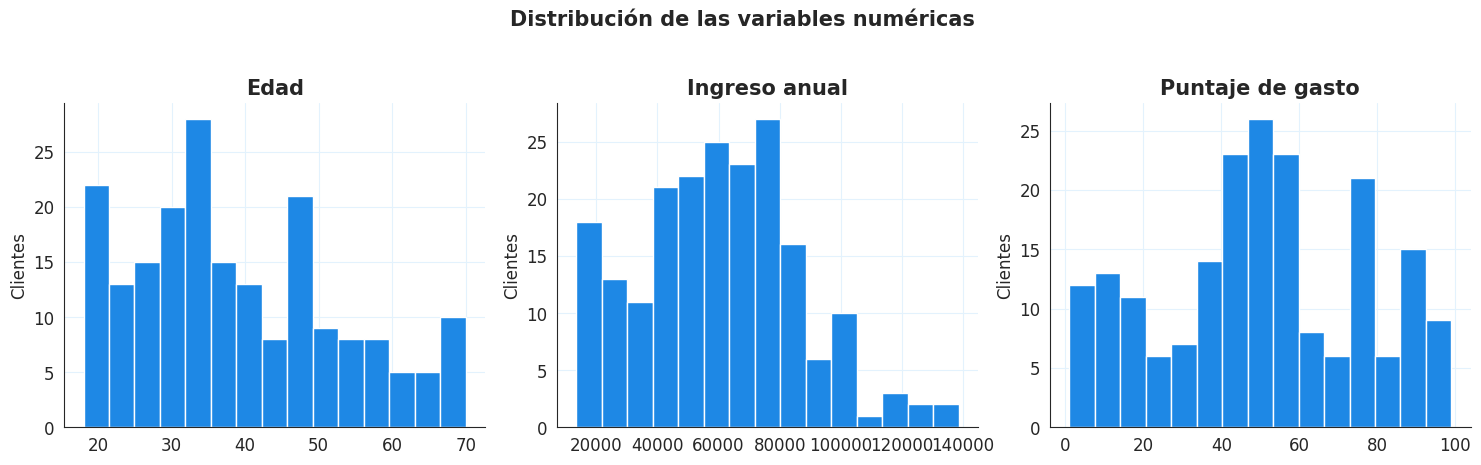

In [ ]:
# Distribución de Edad, Ingreso y Puntaje de Gasto
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, titulo in zip(
    axes,
    ["Edad", "Ingreso", "Puntaje_Gasto"],
    ["Edad", "Ingreso anual", "Puntaje de gasto"]
):
    ax.hist(df[col], bins=15, color=AZUL_MEDIO, edgecolor="white")
    ax.set_title(titulo)
    ax.set_ylabel("Clientes")

plt.suptitle("Distribución de las variables numéricas", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

La base contiene 200 clientes y no presenta valores faltantes. La edad promedio es de 38,85 años, con clientes entre 18 y 70 años. El ingreso anual presenta una dispersión amplia, con valores entre aproximadamente 13.458 y 138.585. El puntaje de gasto también cubre prácticamente toda la escala disponible, desde 1 hasta 99.

Esta variabilidad sugiere que los clientes no presentan un comportamiento homogéneo y justifica explorar si existen grupos diferenciados dentro de la base.

### Composición de la base

Además de las variables numéricas, se revisa cómo están distribuidos los clientes según género y edad.
Esto permitirá posteriormente evaluar si estas características están relacionadas con diferencias en ingreso o comportamiento de gasto.

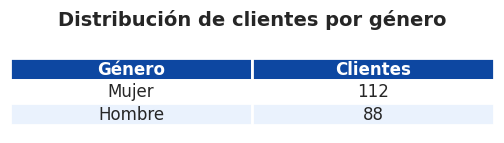

In [ ]:
# Distribución por género
conteo_genero = df["Genero"].value_counts().rename_axis("Género").reset_index(name="Clientes")
tabla_bonita(conteo_genero, "Distribución de clientes por género")

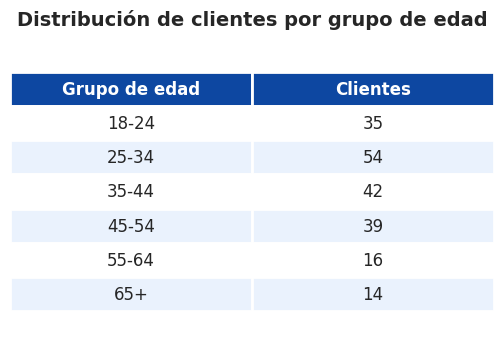

In [ ]:
# Crear grupos de edad
df["Grupo_Edad"] = pd.cut(
    df["Edad"],
    bins=[17, 24, 34, 44, 54, 64, np.inf],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

# Cantidad de clientes por grupo de edad
conteo_edad = df["Grupo_Edad"].value_counts().sort_index().rename_axis("Grupo de edad").reset_index(name="Clientes")
tabla_bonita(conteo_edad, "Distribución de clientes por grupo de edad")

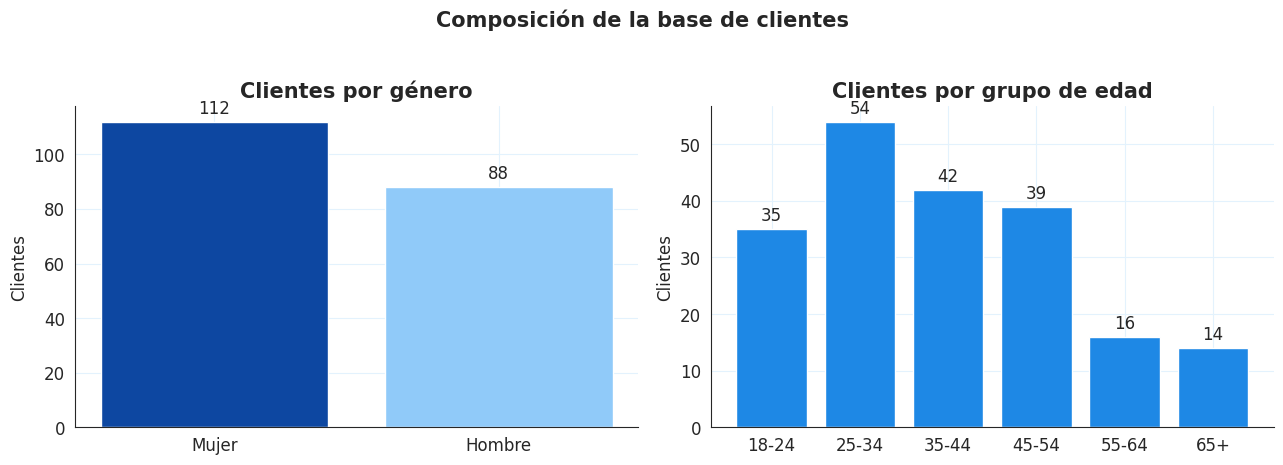

In [ ]:
# Composición de la base: género y grupos de edad
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

barras_genero = axes[0].bar(conteo_genero["Género"], conteo_genero["Clientes"], color=[AZUL_OSCURO, AZUL_CLARO])
axes[0].bar_label(barras_genero, padding=3)
axes[0].set_title("Clientes por género")
axes[0].set_ylabel("Clientes")

barras_edad = axes[1].bar(conteo_edad["Grupo de edad"], conteo_edad["Clientes"], color=AZUL_MEDIO)
axes[1].bar_label(barras_edad, padding=3)
axes[1].set_title("Clientes por grupo de edad")
axes[1].set_ylabel("Clientes")

plt.suptitle("Composición de la base de clientes", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Relación entre ingreso y puntaje de gasto

Se analiza gráficamente la relación entre el ingreso anual y el puntaje de gasto.
El objetivo es identificar si existe a simple vista alguna estructura natural en los datos antes de aplicar los algoritmos de clustering.

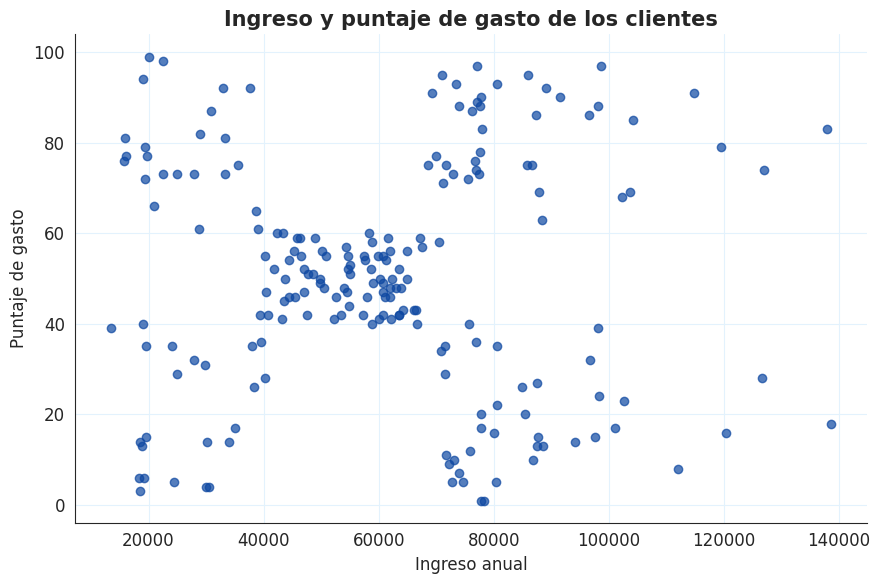

In [ ]:
# Relación entre ingreso y puntaje de gasto
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Ingreso"],
    df["Puntaje_Gasto"],
    alpha=0.7
)

plt.title("Ingreso y puntaje de gasto de los clientes")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")

plt.tight_layout()
plt.show()

A simple vista se observa cierta estructura en la relación entre ingreso y puntaje de gasto. Se distinguen varias concentraciones de clientes, especialmente en los extremos de gasto alto y bajo para diferentes niveles de ingreso, además de un grupo más concentrado alrededor de valores medios.

Visualmente podría pensarse en aproximadamente cinco grupos, aunque esta separación no es completamente evidente para todas las observaciones. Por esta razón, la inspección gráfica sirve como una primera señal, pero no es suficiente para definir el número de segmentos sin aplicar posteriormente los métodos de clustering.

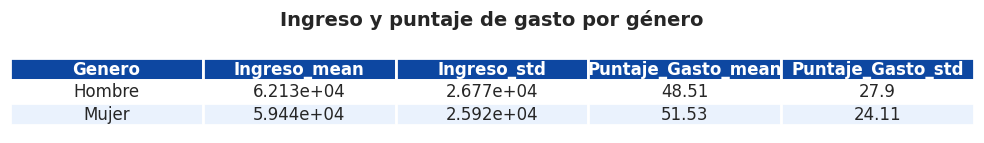

In [ ]:
# Promedios de ingreso y gasto por género
comparacion_genero = (
    df.groupby("Genero")[["Ingreso", "Puntaje_Gasto"]]
    .agg(["mean", "std"])
    .round(2)
)
comparacion_genero.columns = ["_".join(col) for col in comparacion_genero.columns]
tabla_bonita(comparacion_genero.reset_index(), "Ingreso y puntaje de gasto por género")

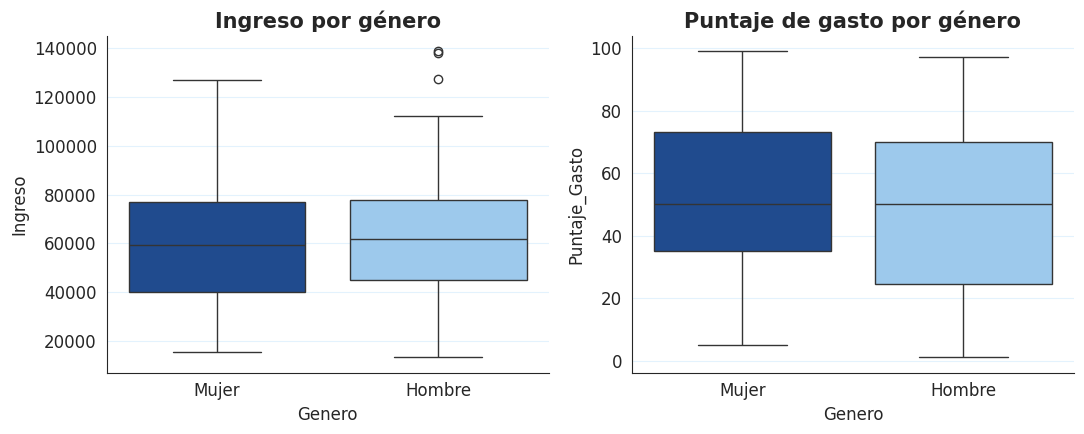

In [ ]:
# Gráfica ingreso y gasto por género
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.boxplot(data=df, x="Genero", y="Ingreso", ax=axes[0], palette=[AZUL_OSCURO, AZUL_CLARO], hue="Genero", legend=False)
axes[0].set_title("Ingreso por género")

sns.boxplot(data=df, x="Genero", y="Puntaje_Gasto", ax=axes[1], palette=[AZUL_OSCURO, AZUL_CLARO], hue="Genero", legend=False)
axes[1].set_title("Puntaje de gasto por género")

plt.tight_layout()
plt.show()

### Comparación estadística por género

Además de comparar visualmente los grupos, se evalúa si las diferencias observadas entre hombres y mujeres en ingreso y puntaje de gasto son estadísticamente significativas.

In [ ]:
# Separar los grupos por género
mujeres = df[df["Genero"] == "Mujer"]
hombres = df[df["Genero"] == "Hombre"]

# Prueba t para ingreso
t_ingreso, p_ingreso = stats.ttest_ind(
    mujeres["Ingreso"],
    hombres["Ingreso"],
    equal_var=False
)

# Prueba t para puntaje de gasto
t_gasto, p_gasto = stats.ttest_ind(
    mujeres["Puntaje_Gasto"],
    hombres["Puntaje_Gasto"],
    equal_var=False
)

print(f"Ingreso - p-valor: {p_ingreso:.4f}")
print(f"Puntaje de gasto - p-valor: {p_gasto:.4f}")

Ingreso - p-valor: 0.4765
Puntaje de gasto - p-valor: 0.4220


Las diferencias observadas entre hombres y mujeres son pequeñas. Los hombres presentan un ingreso promedio ligeramente mayor, mientras que las mujeres tienen un puntaje de gasto promedio algo superior.

Sin embargo, las pruebas estadísticas no muestran diferencias significativas ni en ingreso ni en puntaje de gasto. Por tanto, con esta información no existe evidencia suficiente para afirmar que el género esté asociado con comportamientos de compra diferentes.

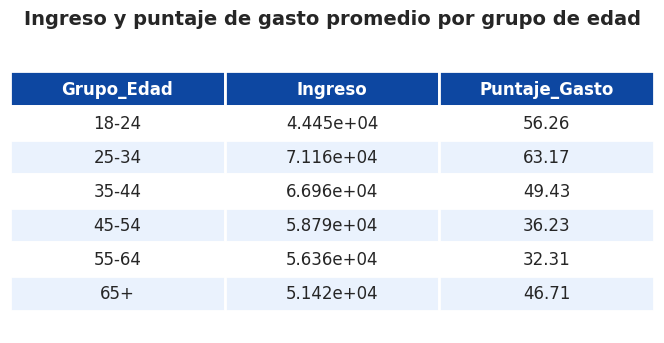

In [ ]:
# Promedios por grupo de edad
comparacion_edad = (
    df.groupby(
        "Grupo_Edad",
        observed=False
    )[["Ingreso", "Puntaje_Gasto"]]
    .mean()
    .round(2)
)
tabla_bonita(comparacion_edad.reset_index(), "Ingreso y puntaje de gasto promedio por grupo de edad")

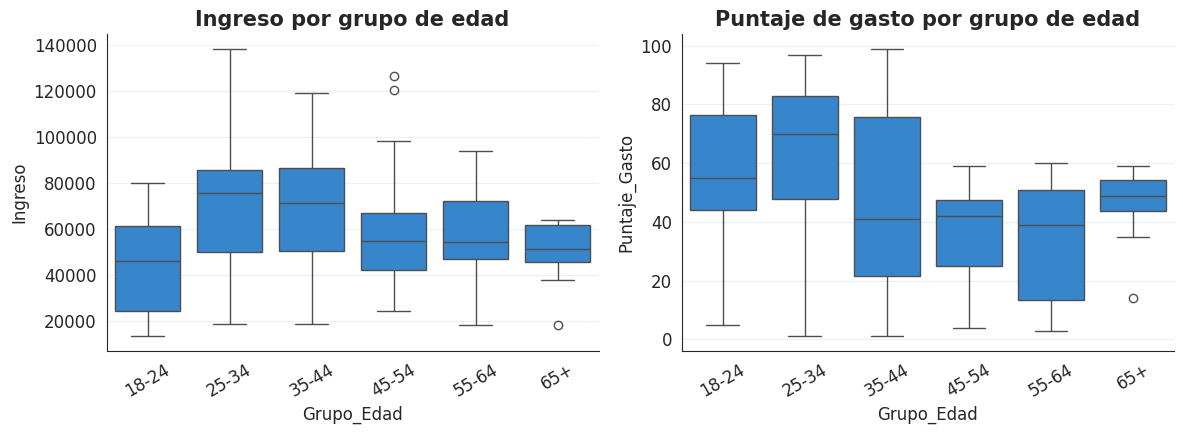

In [ ]:
# Gráfica: ingreso y gasto por grupo de edad
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="Grupo_Edad", y="Ingreso", ax=axes[0], order=conteo_edad["Grupo de edad"], color=AZUL_MEDIO)
axes[0].set_title("Ingreso por grupo de edad")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="Grupo_Edad", y="Puntaje_Gasto", ax=axes[1], order=conteo_edad["Grupo de edad"], color=AZUL_MEDIO)
axes[1].set_title("Puntaje de gasto por grupo de edad")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### ¿Existen diferencias entre los grupos de edad?

In [ ]:
# Crear grupos para la prueba ANOVA
grupos_ingreso = [
    grupo["Ingreso"].values
    for _, grupo in df.groupby("Grupo_Edad", observed=False)
]

grupos_gasto = [
    grupo["Puntaje_Gasto"].values
    for _, grupo in df.groupby("Grupo_Edad", observed=False)
]

# ANOVA para ingreso
f_ingreso, p_ingreso_edad = stats.f_oneway(*grupos_ingreso)

# ANOVA para puntaje de gasto
f_gasto, p_gasto_edad = stats.f_oneway(*grupos_gasto)

print(f"Ingreso por grupo de edad - p-valor: {p_ingreso_edad:.4f}")
print(f"Puntaje de gasto por grupo de edad - p-valor: {p_gasto_edad:.4f}")

Ingreso por grupo de edad - p-valor: 0.0000
Puntaje de gasto por grupo de edad - p-valor: 0.0000


A diferencia de lo observado para género, los grupos de edad sí presentan diferencias importantes. Los clientes entre 25 y 34 años muestran el mayor ingreso promedio y también el mayor puntaje de gasto. En contraste, los grupos entre 45 y 64 años presentan niveles de gasto promedio considerablemente menores.

Las pruebas ANOVA muestran diferencias estadísticamente significativas tanto para ingreso como para puntaje de gasto. Esto indica que la edad sí está relacionada con diferencias en el comportamiento de los clientes y podría aportar información relevante en etapas posteriores del análisis.

## Paso 2. Clustering jerárquico

### 2.1 Preparación de los datos para clustering jerárquico

El análisis se realiza inicialmente utilizando ingreso y puntaje de gasto, las dos variables relacionadas directamente con el comportamiento comercial de los clientes.

Debido a que ambas variables se encuentran en escalas diferentes, se construye una versión estandarizada para evitar que la variable de mayor magnitud tenga mayor influencia sobre las distancias. Más adelante se comparará este resultado con el obtenido sin estandarizar.

In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.metrics import silhouette_score

In [ ]:
# Variables para clustering
variables_cluster = ["Ingreso", "Puntaje_Gasto"]

X_cluster = df[variables_cluster]

# Estandarizar
scaler = StandardScaler()
X_std = scaler.fit_transform(X_cluster)

print("Dimensión de los datos:", X_cluster.shape)

Dimensión de los datos: (200, 2)


### Clustering jerárquico con enlace de Ward y datos estandarizados

Como primera configuración se utiliza el enlace de Ward con distancia euclidiana sobre ingreso y puntaje de gasto estandarizados.

Ward busca formar grupos internamente homogéneos, procurando que al unir dos clusters el aumento de la variabilidad dentro de los grupos sea lo menor posible.

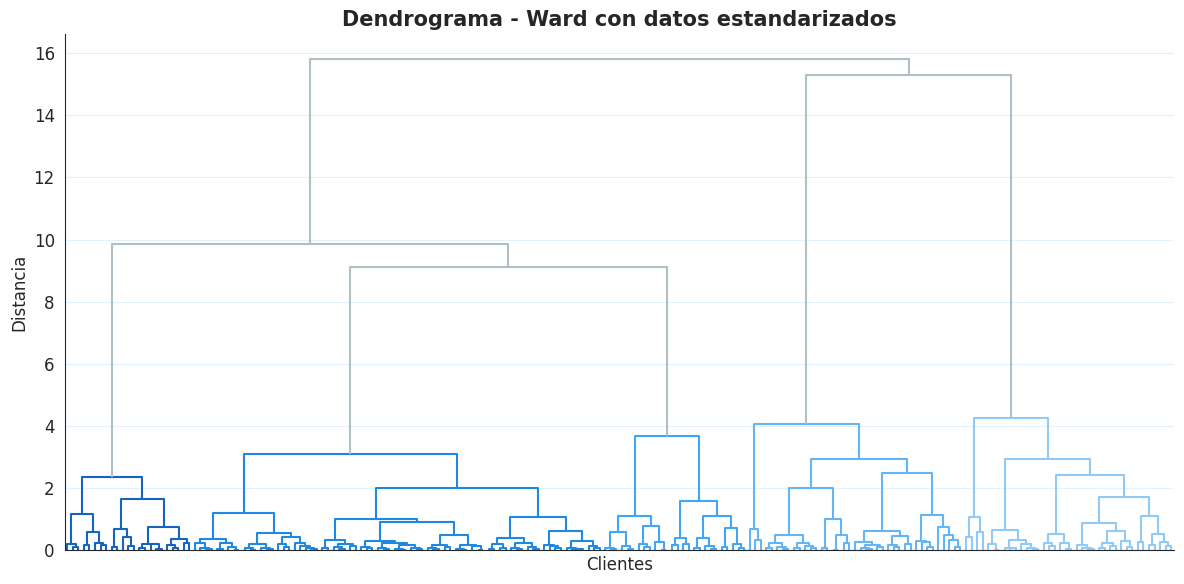

In [ ]:
# Matriz de distancias euclidianas
dist_std = pdist(X_std, metric="euclidean")

# Clustering jerárquico con Ward
Z_ward_std = linkage(dist_std, method="ward")

# Dendrograma
plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward_std,
    no_labels=True,
    color_threshold=Z_ward_std[-4, 2],
    above_threshold_color="#B0BEC5"
)

plt.title("Dendrograma - Ward con datos estandarizados")
plt.xlabel("Clientes")
plt.ylabel("Distancia")

plt.tight_layout()
plt.show()

### Evaluación del número de clusters

El dendrograma permite identificar posibles puntos de corte, pero la elección del número de grupos no debe depender únicamente de la inspección visual.

Como complemento, se calcula el coeficiente de silueta para diferentes números de clusters. Un valor mayor indica una mejor separación entre los grupos.

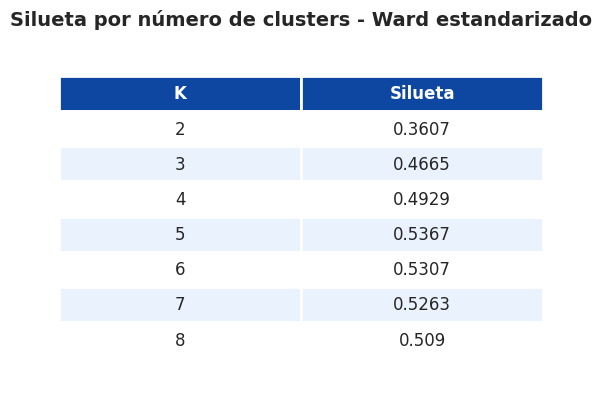

In [ ]:
# Evaluar diferentes números de clusters
Ks = range(2, 9)
silueta_ward_std = []

for k in Ks:
    etiquetas = fcluster(
        Z_ward_std,
        t=k,
        criterion="maxclust"
    )

    silueta = silhouette_score(X_std, etiquetas)
    silueta_ward_std.append(silueta)

resultados_ward_std = pd.DataFrame({
    "K": list(Ks),
    "Silueta": silueta_ward_std
})

tabla_bonita(resultados_ward_std, "Silueta por número de clusters - Ward estandarizado")

Con enlace de Ward sobre las variables estandarizadas, el coeficiente de silueta mejora progresivamente hasta alcanzar su mayor valor en **K=5 (0,5367)**. A partir de este punto la calidad del agrupamiento comienza a disminuir ligeramente.

Este resultado respalda la presencia de aproximadamente cinco grupos en los datos, lo cual también es consistente con la estructura que se observó inicialmente en la relación entre ingreso y puntaje de gasto. Por tanto, K=5 aparece como un punto de corte razonable para esta configuración.

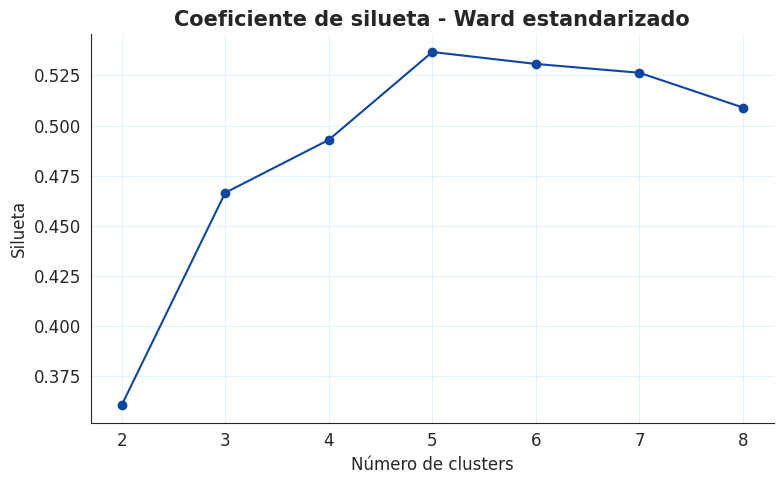

In [ ]:
# Visualizar la silueta según el número de clusters
plt.figure(figsize=(8, 5))

plt.plot(
    list(Ks),
    silueta_ward_std,
    marker="o"
)

plt.title("Coeficiente de silueta - Ward estandarizado")
plt.xlabel("Número de clusters")
plt.ylabel("Silueta")
plt.xticks(list(Ks))

plt.tight_layout()
plt.show()

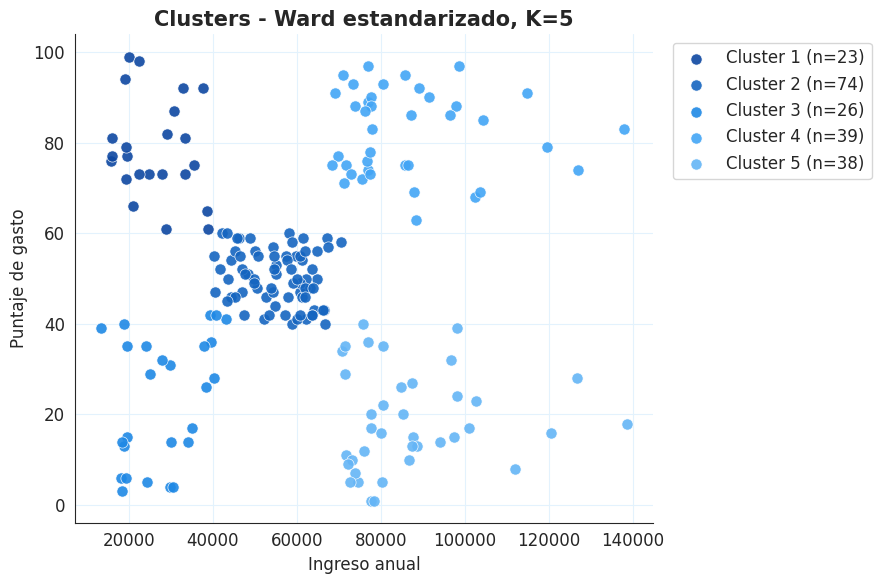

In [ ]:
# Clusters resultantes con Ward estandarizado, K=5
etiquetas_ward5 = fcluster(Z_ward_std, t=5, criterion="maxclust")

plt.figure(figsize=(9, 6))
for k in sorted(set(etiquetas_ward5)):
    mask = etiquetas_ward5 == k
    plt.scatter(df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
                color=PALETA_AZUL[(k-1) % len(PALETA_AZUL)],
                edgecolor="white", linewidth=0.5, s=65, alpha=0.9,
                label=f"Cluster {k} (n={mask.sum()})")

plt.title("Clusters - Ward estandarizado, K=5")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

### Sensibilidad al método de enlace

Para evaluar si la estructura encontrada depende del método utilizado, se repite el análisis con enlace completo manteniendo las mismas variables estandarizadas y la distancia euclidiana.

A diferencia de Ward, el enlace completo determina la distancia entre dos clusters a partir de las observaciones más alejadas entre ambos grupos.

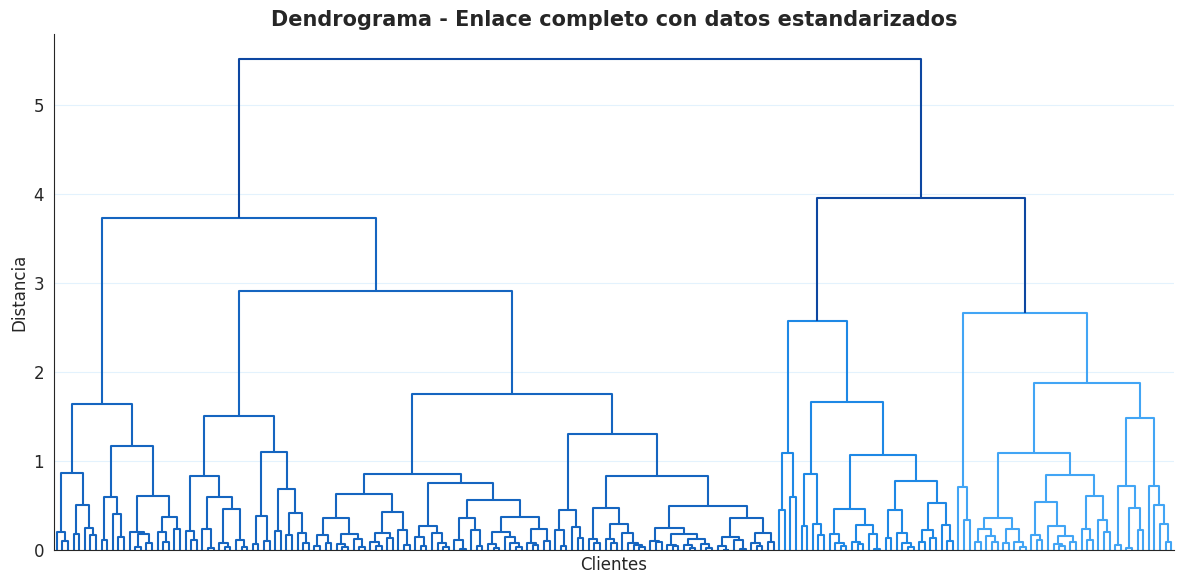

In [ ]:
# Clustering jerárquico con enlace completo
Z_complete_std = linkage(
    dist_std,
    method="complete"
)

# Dendrograma
plt.figure(figsize=(12, 6))

dendrogram(
    Z_complete_std,
    no_labels=True
)

plt.title("Dendrograma - Enlace completo con datos estandarizados")
plt.xlabel("Clientes")
plt.ylabel("Distancia")

plt.tight_layout()
plt.show()

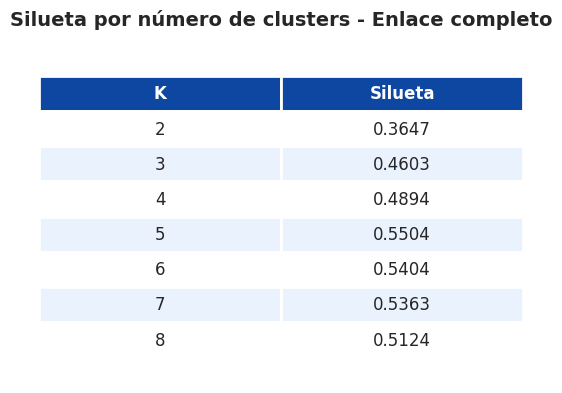

In [ ]:
# Silueta para enlace completo
silueta_complete_std = []

for k in Ks:
    etiquetas = fcluster(
        Z_complete_std,
        t=k,
        criterion="maxclust"
    )

    silueta = silhouette_score(X_std, etiquetas)
    silueta_complete_std.append(silueta)

resultados_complete_std = pd.DataFrame({
    "K": list(Ks),
    "Silueta": silueta_complete_std
})

tabla_bonita(resultados_complete_std, "Silueta por número de clusters - Enlace completo")

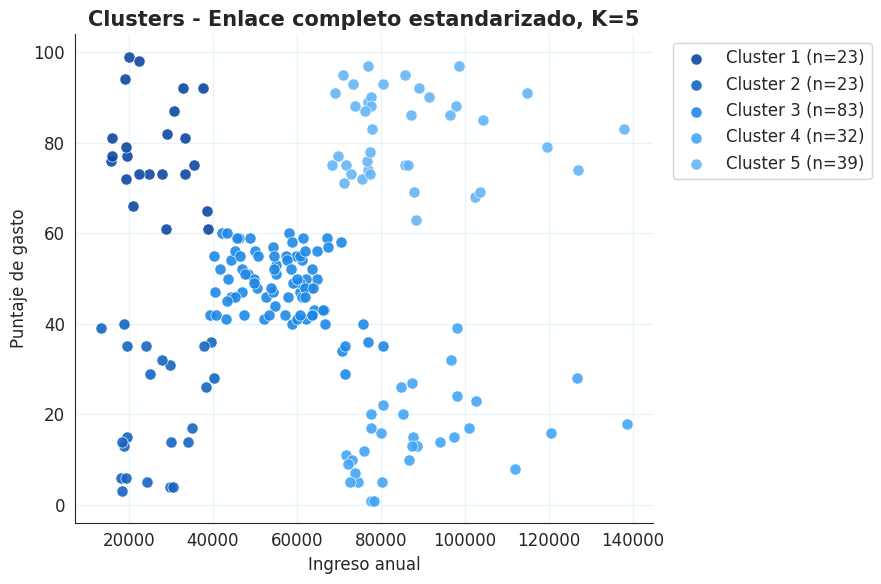

In [ ]:
# Clusters resultantes con enlace completo, K=5
etiquetas_complete5 = fcluster(Z_complete_std, t=5, criterion="maxclust")

plt.figure(figsize=(9, 6))
for k in sorted(set(etiquetas_complete5)):
    mask = etiquetas_complete5 == k
    plt.scatter(df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
                color=PALETA_AZUL[(k-1) % len(PALETA_AZUL)],
                edgecolor="white", linewidth=0.5, s=65, alpha=0.9,
                label=f"Cluster {k} (n={mask.sum()})")

plt.title("Clusters - Enlace completo estandarizado, K=5")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Al cambiar el método de enlace de Ward a enlace completo, el mejor resultado continúa encontrándose en **K=5**, con una silueta de **0,5504**.

Que dos métodos de enlace diferentes identifiquen cinco grupos como la mejor alternativa sugiere que esta estructura no depende únicamente de una decisión particular del algoritmo. Además, el enlace completo presenta una silueta ligeramente superior a Ward, aunque ambos producen resultados bastante similares.

### Efecto de no estandarizar las variables

Finalmente, se repite el clustering con enlace de Ward utilizando ingreso y puntaje de gasto en sus escalas originales.

Esta configuración permite evaluar cuánto cambia la segmentación cuando las diferencias de escala entre las variables se mantienen.

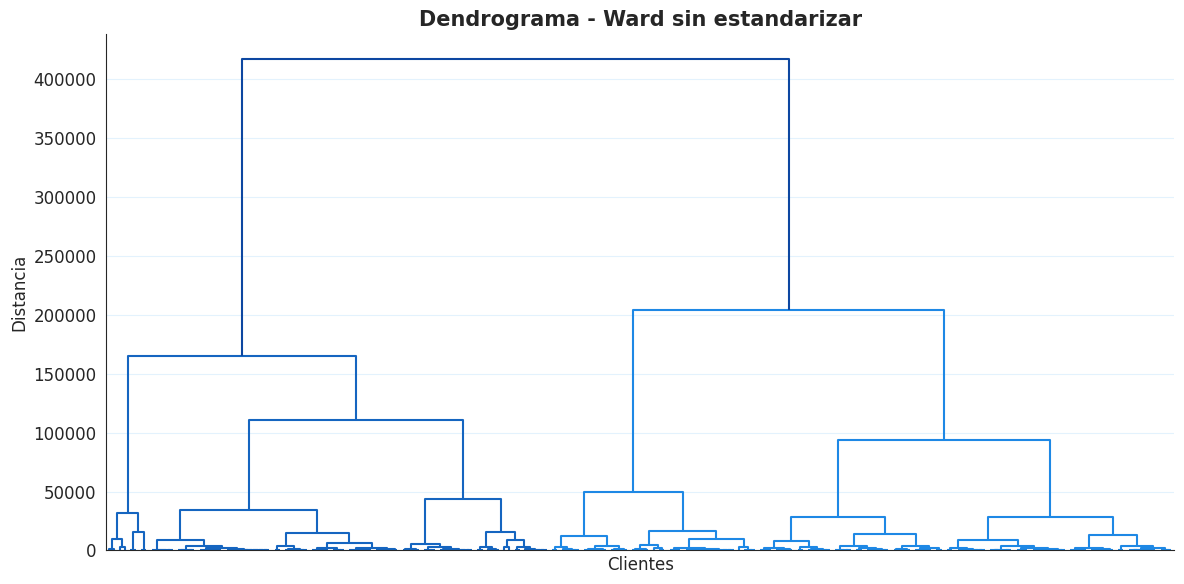

In [ ]:
# Distancias con las variables originales
dist_crudo = pdist(
    X_cluster,
    metric="euclidean"
)

# Ward sin estandarizar
Z_ward_crudo = linkage(
    dist_crudo,
    method="ward"
)

# Dendrograma
plt.figure(figsize=(12, 6))

dendrogram(
    Z_ward_crudo,
    no_labels=True
)

plt.title("Dendrograma - Ward sin estandarizar")
plt.xlabel("Clientes")
plt.ylabel("Distancia")

plt.tight_layout()
plt.show()

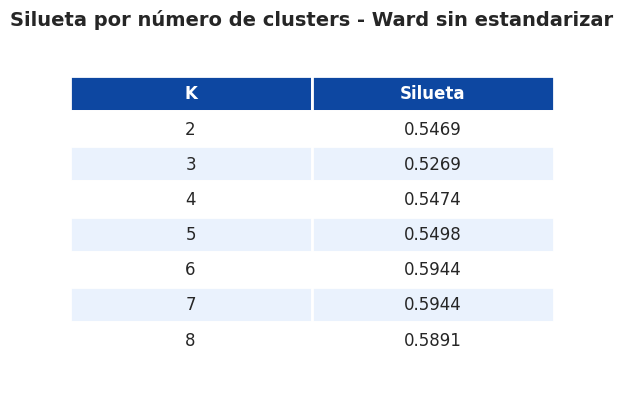

In [ ]:
# Silueta para Ward sin estandarizar
silueta_ward_crudo = []

for k in Ks:
    etiquetas = fcluster(
        Z_ward_crudo,
        t=k,
        criterion="maxclust"
    )

    silueta = silhouette_score(
        X_cluster,
        etiquetas
    )

    silueta_ward_crudo.append(silueta)

resultados_ward_crudo = pd.DataFrame({
    "K": list(Ks),
    "Silueta": silueta_ward_crudo
})

tabla_bonita(resultados_ward_crudo, "Silueta por número de clusters - Ward sin estandarizar")

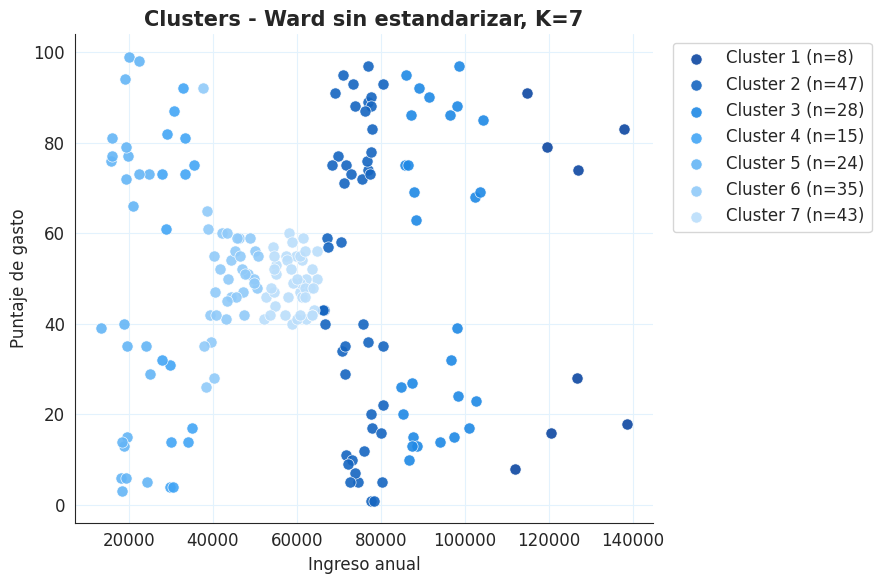

In [ ]:
# Clusters resultantes con Ward sin estandarizar, mejor K
mejor_k_crudo = list(Ks)[np.argmax(silueta_ward_crudo)]
etiquetas_crudo = fcluster(Z_ward_crudo, t=mejor_k_crudo, criterion="maxclust")

plt.figure(figsize=(9, 6))
for k in sorted(set(etiquetas_crudo)):
    mask = etiquetas_crudo == k
    plt.scatter(df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
                color=PALETA_AZUL[(k-1) % len(PALETA_AZUL)],
                edgecolor="white", linewidth=0.5, s=65, alpha=0.9,
                label=f"Cluster {k} (n={mask.sum()})")

plt.title(f"Clusters - Ward sin estandarizar, K={mejor_k_crudo}")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

Al utilizar las variables sin estandarizar, los valores de silueta aumentan y los mayores resultados aparecen en K=6 y K=7, con valores prácticamente idénticos (aproximadamente 0,5944).

Sin embargo, este resultado debe interpretarse con precaución. El ingreso se encuentra en una escala de decenas de miles, mientras que el puntaje de gasto varía entre 1 y 99. Al calcular distancias sin estandarizar, el ingreso tiene una influencia mucho mayor sobre la formación de los grupos.

Por esta razón, una silueta superior en esta configuración no implica necesariamente una mejor segmentación para el problema de negocio, ya que los grupos pueden estar reflejando principalmente diferencias de ingreso y dejando en segundo plano el comportamiento de gasto.

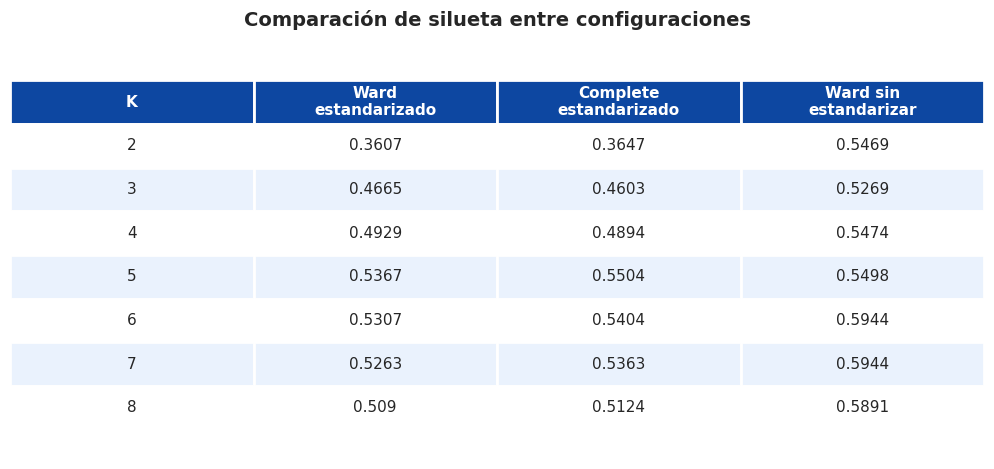

In [ ]:
# Comparar las tres configuraciones
comparacion_jerarquico = pd.DataFrame({
    "K": list(Ks),
    "Ward estandarizado": silueta_ward_std,
    "Complete estandarizado": silueta_complete_std,
    "Ward sin estandarizar": silueta_ward_crudo
})

tabla_bonita(comparacion_jerarquico.round(4), "Comparación de silueta entre configuraciones")

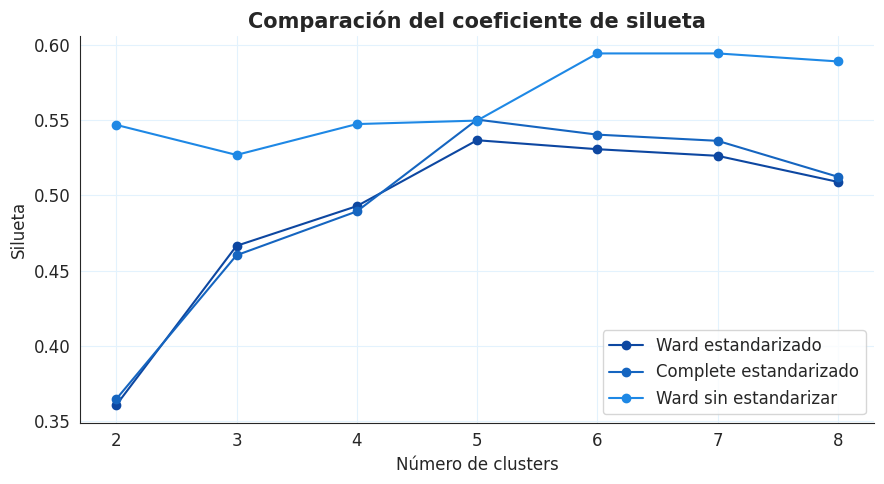

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    comparacion_jerarquico["K"],
    comparacion_jerarquico["Ward estandarizado"],
    marker="o",
    label="Ward estandarizado"
)

plt.plot(
    comparacion_jerarquico["K"],
    comparacion_jerarquico["Complete estandarizado"],
    marker="o",
    label="Complete estandarizado"
)

plt.plot(
    comparacion_jerarquico["K"],
    comparacion_jerarquico["Ward sin estandarizar"],
    marker="o",
    label="Ward sin estandarizar"
)

plt.title("Comparación del coeficiente de silueta")
plt.xlabel("Número de clusters")
plt.ylabel("Silueta")
plt.xticks(list(Ks))
plt.legend()

plt.tight_layout()
plt.show()

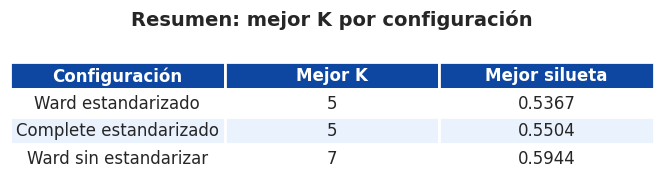

In [ ]:
resumen_jerarquico = pd.DataFrame({
    "Configuración": [
        "Ward estandarizado",
        "Complete estandarizado",
        "Ward sin estandarizar"
    ],
    "Mejor K": [
        list(Ks)[np.argmax(silueta_ward_std)],
        list(Ks)[np.argmax(silueta_complete_std)],
        list(Ks)[np.argmax(silueta_ward_crudo)]
    ],
    "Mejor silueta": [
        max(silueta_ward_std),
        max(silueta_complete_std),
        max(silueta_ward_crudo)
    ]
})

tabla_bonita(resumen_jerarquico.round(4), "Resumen: mejor K por configuración")

### Conclusión del clustering jerárquico

La comparación muestra que las dos configuraciones construidas sobre variables estandarizadas coinciden en una solución de cinco clusters. Ward alcanza una silueta de 0,5367 y enlace completo una de 0,5504, lo que indica que la estructura de cinco grupos se mantiene incluso al cambiar el método de enlace.

Aunque Ward sin estandarizar obtiene valores de silueta mayores, su solución cambia hacia seis o siete grupos y está fuertemente condicionada por la escala del ingreso. Por ello, no se considera suficiente utilizar únicamente la mayor silueta para seleccionar esta configuración.

En conjunto, la evidencia favorece una estructura de cinco segmentos utilizando las variables estandarizadas, ya que permite que ingreso y puntaje de gasto tengan una influencia comparable y muestra estabilidad frente al cambio de método de enlace.

## Paso 3. DBSCAN

### 3.1 Elección de hiperparámetros (eps y min_samples)

DBSCAN se aplica sobre las mismas dos variables estandarizadas usadas en el clustering jerárquico (ingreso y puntaje de gasto), para que los resultados sean comparables.

`min_samples` se fija en 5. Para elegir `eps` se usa el gráfico de distancia al k-ésimo vecino: se busca el "codo" donde la distancia empieza a crecer rápido.

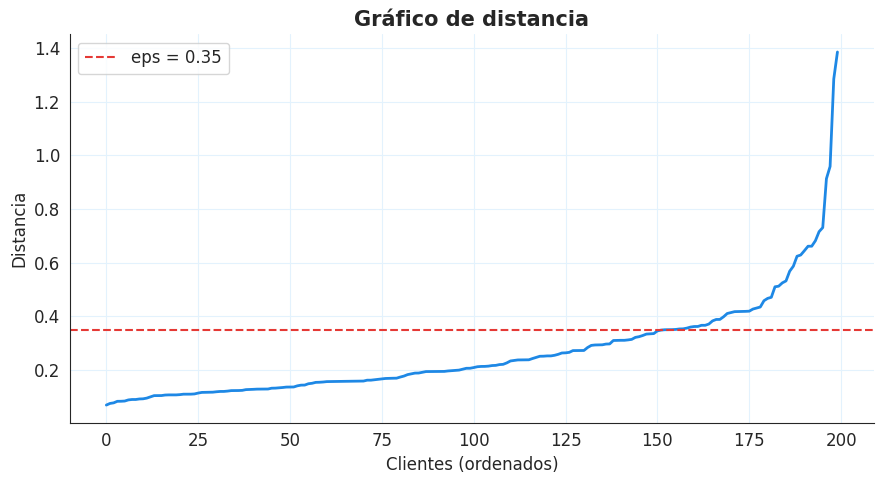

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

min_samples = 5

# Distancia al k-ésimo vecino más cercano (k = min_samples)
vecinos = NearestNeighbors(n_neighbors=min_samples).fit(X_std)
distancias, _ = vecinos.kneighbors(X_std)
k_distancias = np.sort(distancias[:, min_samples - 1])

plt.figure(figsize=(9, 5))
plt.plot(k_distancias, color=AZUL_MEDIO, linewidth=2)
plt.axhline(0.35, color=ACENTO, linestyle="--", label="eps = 0.35")

plt.title(f"Gráfico de distancia")
plt.xlabel("Clientes (ordenados)")
plt.ylabel("Distancia")
plt.legend()

plt.tight_layout()
plt.show()

El codo del gráfico se ubica alrededor de **eps = 0.35**: antes de ese punto la distancia crece lentamente y después crece de rápidamente Se usa ese valor como valor inicial.

### 3.2 Hiperparámetros

In [ ]:
# Ejecucuión de eps y min_samples
eps_grid = [0.2, 0.25, 0.3, 0.35, 0.4]
ms_grid = [4, 5, 6]

resultados_dbscan = []
for eps in eps_grid:
    for ms in ms_grid:
        etiquetas = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_std)
        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_ruido = int((etiquetas == -1).sum())

        sin_ruido = etiquetas != -1
        if n_clusters >= 2 and len(set(etiquetas[sin_ruido])) > 1:
            sil = silhouette_score(X_std[sin_ruido], etiquetas[sin_ruido])
        else:
            sil = np.nan

        resultados_dbscan.append({
            "eps": eps,
            "min_samples": ms,
            "Clusters": n_clusters,
            "% Ruido": n_ruido / len(df),
            "Silueta": sil
        })

resultados_dbscan = pd.DataFrame(resultados_dbscan)
resultados_dbscan.round(3)

,eps,min_samples,Clusters,% Ruido,Silueta
0,0.20,4,8,0.335,0.595
1,0.20,5,5,0.450,0.631
2,0.20,6,5,0.460,0.625
3,0.25,4,9,0.190,0.424
4,0.25,5,7,0.275,0.494
5,0.25,6,7,0.310,0.620
6,0.30,4,7,0.110,0.483
7,0.30,5,7,0.160,0.517
8,0.30,6,7,0.205,0.539
9,0.35,4,5,0.095,0.544


LA ejecución muestra un patrón claro: con eps pequeño (0.2) el algoritmo produce muchos micro-grupos y deja hasta el 45% de los clientes como ruido; con eps grande (0.4) casi todo el ruido desaparece pero el número de clusters colapsa a 2-4, mezclando perfiles distintos en un mismo grupo.

La zona intermedia, eps = 0.35 con min_samples = 5, produce 5 clusters con silueta de 0.548 y un nivel de ruido moderado, consistente con la estructura de cinco grupos ya encontrada en el clustering jerárquico.

### 3.3 Solución y visualización

Clusters encontrados: 5
Clientes marcados como ruido: 22 (11.0%)


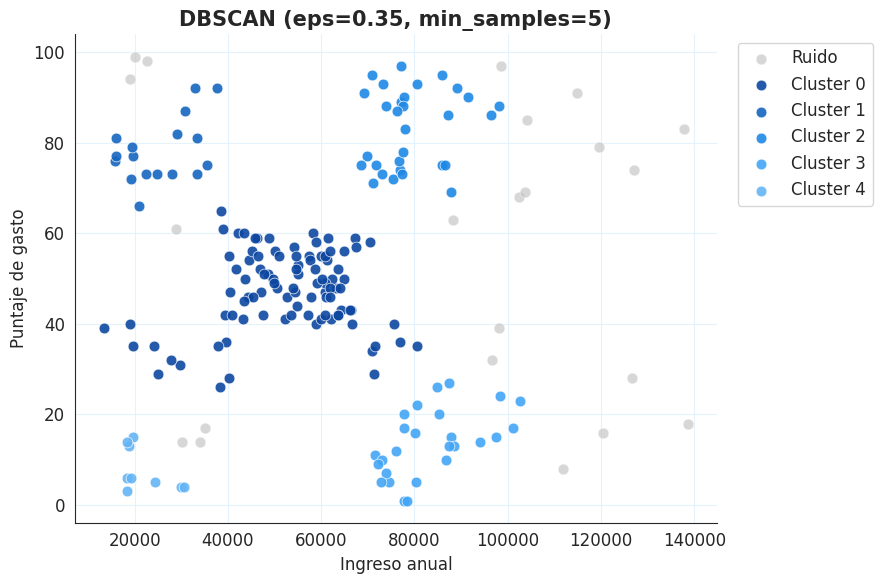

In [ ]:
# Configuración elegida
eps_final = 0.35
ms_final = 5

etiquetas_dbscan = DBSCAN(eps=eps_final, min_samples=ms_final).fit_predict(X_std)

n_clusters_db = len(set(etiquetas_dbscan)) - (1 if -1 in etiquetas_dbscan else 0)
n_ruido_db = int((etiquetas_dbscan == -1).sum())
print(f"Clusters encontrados: {n_clusters_db}")
print(f"Clientes marcados como ruido: {n_ruido_db} ({n_ruido_db/len(df):.1%})")

# Visualización de los clusters (el ruido se muestra en gris)
plt.figure(figsize=(9, 6))

colores = {i: PALETA_AZUL[i % len(PALETA_AZUL)] for i in sorted(set(etiquetas_dbscan)) if i != -1}
colores[-1] = "#BDBDBD"

for etiqueta in sorted(set(etiquetas_dbscan)):
    mask = etiquetas_dbscan == etiqueta
    nombre = "Ruido" if etiqueta == -1 else f"Cluster {etiqueta}"
    plt.scatter(
        df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
        color=colores[etiqueta], label=nombre,
        edgecolor="white", linewidth=0.5, s=60,
        alpha=0.9 if etiqueta != -1 else 0.6
    )

plt.title(f"DBSCAN (eps={eps_final}, min_samples={ms_final})")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

### Sensibilidad de hiperparámetros

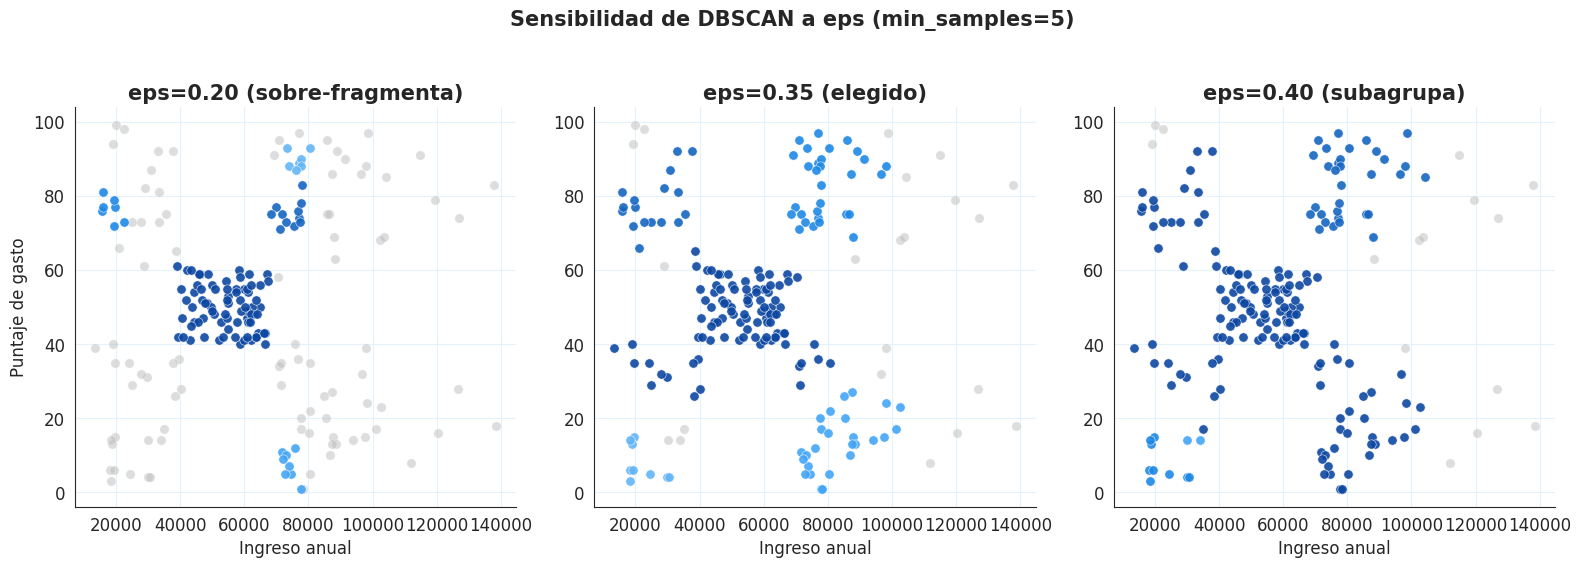

In [ ]:
# Comparación visual: eps pequeño vs. elegido vs. grande
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, eps_i, ms_i, titulo in zip(
    axes,
    [0.2, 0.35, 0.4],
    [5, 5, 5],
    ["eps=0.20 (sobre-fragmenta)", "eps=0.35 (elegido)", "eps=0.40 (subagrupa)"]
):
    etiquetas_i = DBSCAN(eps=eps_i, min_samples=ms_i).fit_predict(X_std)
    colores_i = {k: PALETA_AZUL[k % len(PALETA_AZUL)] for k in sorted(set(etiquetas_i)) if k != -1}
    colores_i[-1] = "#BDBDBD"
    for k in sorted(set(etiquetas_i)):
        mask = etiquetas_i == k
        ax.scatter(df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
                   color=colores_i[k], edgecolor="white", linewidth=0.4, s=45,
                   alpha=0.9 if k != -1 else 0.5)
    ax.set_title(titulo)
    ax.set_xlabel("Ingreso anual")
    if ax is axes[0]:
        ax.set_ylabel("Puntaje de gasto")

plt.suptitle("Sensibilidad de DBSCAN a eps (min_samples=5)", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

### Conclusión DBSCAN
El algoritmo no encuentra suficiente densidad alrededor de clientes marcados como ruido, son perfiles atípicos. Presentarlos de todos modos como parte de un cluster (como hace el jerárquico, que no tiene la opción de "no clasificar") puede dar una falsa sensación de que todos los clientes encajan perfectamente en un perfil.

DBSCAN con eps=0,35 recupera los mismos 5 grupos que Ward y enlace completo encontraron en el Paso 2, con una silueta similar. La diferencia principal es que DBSCAN además identifica un ~11% de clientes que no pertenecen claramente a ningún perfil, información que el jerárquico oculta al forzar la asignación de todos los puntos.

## Paso 4. Todas las variables

### 4.1 Distancia de Gower

Género y grupo de edad son variables categóricas por lo que se decide utilizar distancia de Gower

In [ ]:
def distancia_gower(datos, columnas_numericas, columnas_categoricas):
    """Matriz de distancias de Gower (n x n) combinando variables numéricas y categóricas."""
    n = len(datos)
    D = np.zeros((n, n))
    n_variables = len(columnas_numericas) + len(columnas_categoricas)

    for col in columnas_numericas:
        x = datos[col].to_numpy(dtype=float)
        rango = x.max() - x.min()
        D += np.abs(x[:, None] - x[None, :]) / rango

    for col in columnas_categoricas:
        x = datos[col].astype(str).to_numpy()
        D += (x[:, None] != x[None, :]).astype(float)

    return D / n_variables

D_gower = distancia_gower(
    df,
    columnas_numericas=["Ingreso", "Puntaje_Gasto"],
    columnas_categoricas=["Genero", "Grupo_Edad"]
)

print("Dimensión de la matriz:", D_gower.shape)
print(f"Distancia mínima: {D_gower[D_gower>0].min():.3f} | máxima: {D_gower.max():.3f}")

Dimensión de la matriz: (200, 200)
Distancia mínima: 0.003 | máxima: 0.944


### 4.2 Jerárquico con distancia de Gower

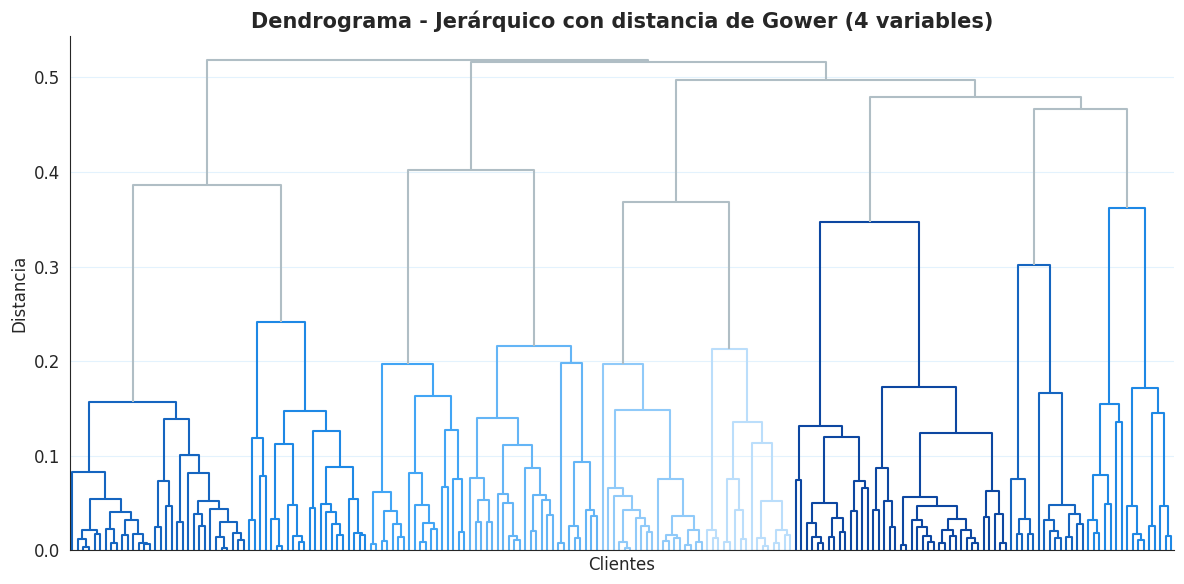

In [ ]:
from scipy.spatial.distance import squareform

# Distancia condensada para linkage
condensada_gower = squareform(D_gower, checks=False)
Z_gower_avg = linkage(condensada_gower, method="average")

plt.figure(figsize=(12, 6))
dendrogram(Z_gower_avg, no_labels=True, color_threshold=Z_gower_avg[-8, 2], above_threshold_color="#B0BEC5")
plt.title("Dendrograma - Jerárquico con distancia de Gower (4 variables)")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()

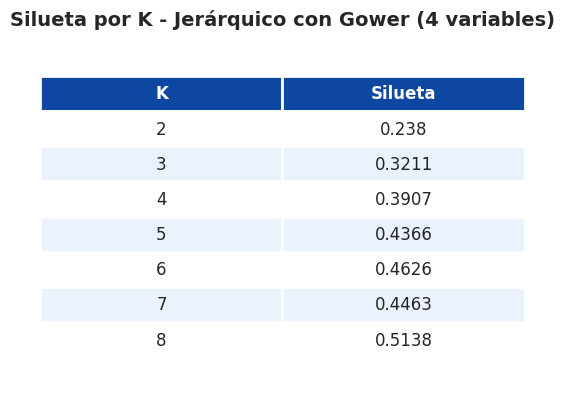

In [ ]:
# Silueta por número de clusters
Ks_g = range(2, 9)
silueta_gower_jer = []

for k in Ks_g:
    etiquetas = fcluster(Z_gower_avg, t=k, criterion="maxclust")
    if len(set(etiquetas)) > 1:
        sil = silhouette_score(D_gower, etiquetas, metric="precomputed")
    else:
        sil = np.nan
    silueta_gower_jer.append(sil)

resultados_gower_jer = pd.DataFrame({"K": list(Ks_g), "Silueta": silueta_gower_jer})
tabla_bonita(resultados_gower_jer.round(4), "Silueta por K - Jerárquico con Gower (4 variables)")

El mejor resultado aparece en **K=8**, con silueta de ~0,51 — igual que con DBSCAN-Gower, el número de grupos se aleja de los 5 encontrados con solo dos variables numéricas.

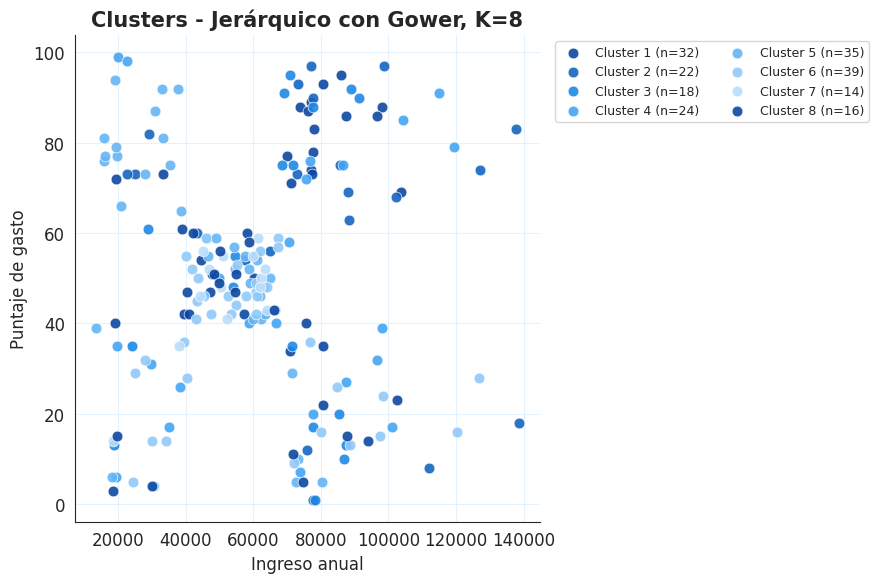

In [ ]:
# Visualización de los clusters jerárquico-Gower (mejor K)
mejor_k_gower = list(Ks_g)[np.nanargmax(silueta_gower_jer)]
etiquetas_gower_jer = fcluster(Z_gower_avg, t=mejor_k_gower, criterion="maxclust")

plt.figure(figsize=(9, 6))
for k in sorted(set(etiquetas_gower_jer)):
    mask = etiquetas_gower_jer == k
    plt.scatter(df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
                color=PALETA_AZUL[(k-1) % len(PALETA_AZUL)],
                edgecolor="white", linewidth=0.5, s=60, alpha=0.9,
                label=f"Cluster {k} (n={mask.sum()})")

plt.title(f"Clusters - Jerárquico con Gower, K={mejor_k_gower}")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

Proyectados sobre ingreso y gasto, los 8 clusters de Gower se ven como los mismos 5 bloques del Paso 2, pero subdivididos internamente por combinaciones de género y grupo de edad.

### 4.3 DBSCAN con distancia de Gower

In [ ]:
# Ejecución de hiperparámetros sobre la matriz de Gower
eps_grid_g = [0.06, 0.08, 0.10, 0.12, 0.15, 0.18]
ms_grid_g = [4, 5, 6]

resultados_gower = []
for eps in eps_grid_g:
    for ms in ms_grid_g:
        etiquetas = DBSCAN(eps=eps, min_samples=ms, metric="precomputed").fit_predict(D_gower)
        n_clusters = len(set(etiquetas)) - (1 if -1 in etiquetas else 0)
        n_ruido = int((etiquetas == -1).sum())

        sin_ruido = etiquetas != -1
        if n_clusters >= 2 and len(set(etiquetas[sin_ruido])) > 1:
            sil = silhouette_score(D_gower[np.ix_(sin_ruido, sin_ruido)], etiquetas[sin_ruido], metric="precomputed")
        else:
            sil = np.nan

        resultados_gower.append({"eps": eps, "min_samples": ms, "Clusters": n_clusters,
                                  "% Ruido": n_ruido/len(df), "Silueta": sil})

resultados_gower = pd.DataFrame(resultados_gower)
resultados_gower.round(3)

,eps,min_samples,Clusters,% Ruido,Silueta
0,0.06,4,15,0.230,0.702
1,0.06,5,12,0.320,0.716
2,0.06,6,10,0.430,0.746
3,0.08,4,14,0.110,0.655
4,0.08,5,13,0.160,0.664
5,0.08,6,10,0.270,0.703
6,0.10,4,13,0.065,0.653
7,0.10,5,11,0.110,0.669
8,0.10,6,9,0.175,0.676
9,0.12,4,14,0.030,0.638


Al incorporar género y grupo de edad, el número de clusters se incrementa: entre 9 y 15 grupos según los hiperparámetros, muy lejos de los 5 encontrados con solo dos variables numéricas. La silueta incluso sube (hasta 0,70), pero eso no significa una mejor segmentación: son grupos más pequeños y más "puros" porque las variables categóricas exigen coincidencia exacta (mismo género y mismo rango de edad) para considerar cercanos a dos clientes.

Con solo dos variables numéricas, cada una pesa 50% de la distancia. Al agregar género (2 categorías) y grupo de edad (6 categorías), dos variables categóricas pasan a pesar el 50% de la distancia total, y dentro de ellas, coincidir en la categoría de edad (6 posibles valores) es mucho más determinante que una pequeña diferencia de ingreso. En la práctica, el algoritmo termina agrupando principalmente por combinaciones de género y rango de edad.

Clusters con las 4 variables (Gower): 11
Ruido: 18 clientes (9.0%)


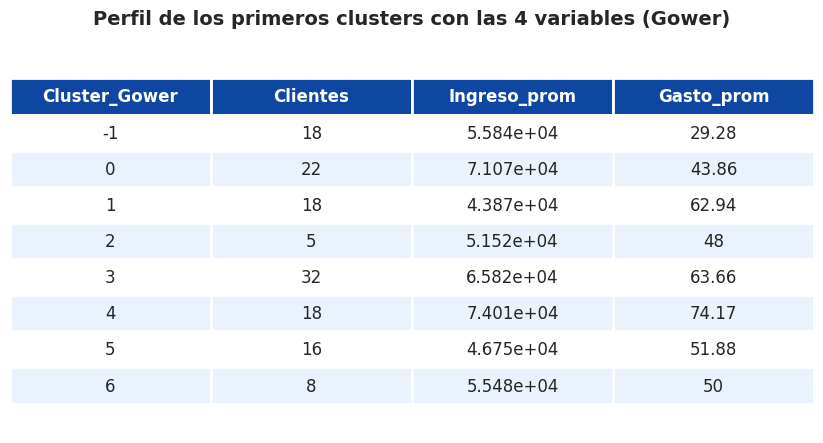

In [ ]:
# Configuración representativa con las cuatro variables
eps_final_g, ms_final_g = 0.12, 5
etiquetas_gower = DBSCAN(eps=eps_final_g, min_samples=ms_final_g, metric="precomputed").fit_predict(D_gower)

n_clusters_g = len(set(etiquetas_gower)) - (1 if -1 in etiquetas_gower else 0)
n_ruido_g = int((etiquetas_gower == -1).sum())
print(f"Clusters con las 4 variables (Gower): {n_clusters_g}")
print(f"Ruido: {n_ruido_g} clientes ({n_ruido_g/len(df):.1%})")

tabla_bonita(
    df.assign(Cluster_Gower=etiquetas_gower)
      .groupby("Cluster_Gower", observed=False)
      .agg(Clientes=("Id_Cliente","count"), Ingreso_prom=("Ingreso","mean"), Gasto_prom=("Puntaje_Gasto","mean"))
      .reset_index()
      .head(8),
    "Perfil de los primeros clusters con las 4 variables (Gower)"
)

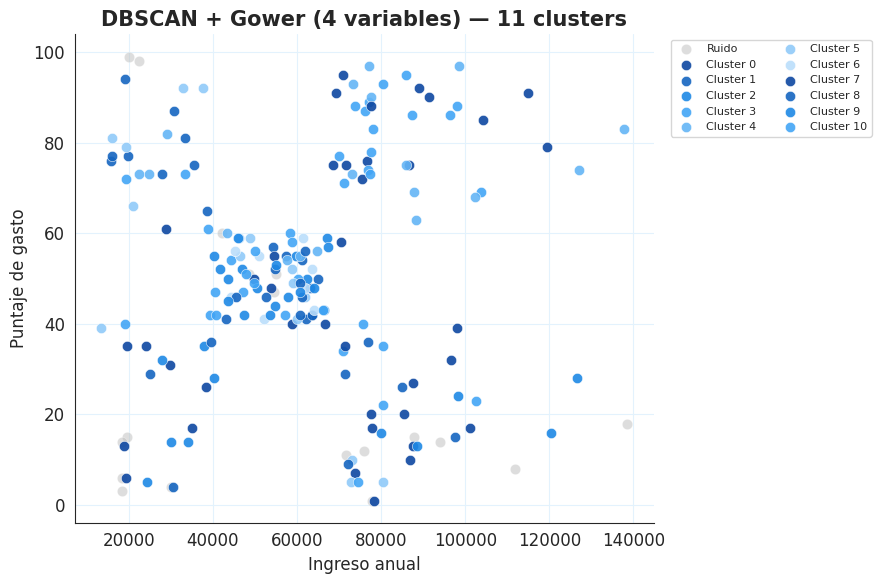

In [ ]:
# Visualización de los clusters DBSCAN + Gower
plt.figure(figsize=(9, 6))

colores_g = {k: PALETA_AZUL[k % len(PALETA_AZUL)] for k in sorted(set(etiquetas_gower)) if k != -1}
colores_g[-1] = "#BDBDBD"

for etiqueta in sorted(set(etiquetas_gower)):
    mask = etiquetas_gower == etiqueta
    nombre = "Ruido" if etiqueta == -1 else f"Cluster {etiqueta}"
    plt.scatter(
        df.loc[mask, "Ingreso"], df.loc[mask, "Puntaje_Gasto"],
        color=colores_g[etiqueta], label=nombre,
        edgecolor="white", linewidth=0.4, s=55,
        alpha=0.9 if etiqueta != -1 else 0.5
    )

plt.title(f"DBSCAN + Gower (4 variables) — {n_clusters_g} clusters")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

En el Paso 1 las pruebas t no mostraron diferencias significativas en ingreso ni en puntaje de gasto entre hombres y mujeres. Segmentar una campaña por una variable que no distingue el comportamiento de compra tendría un costo real para la cadena: dos mensajes y dos canales distintos que le hablarían de forma casi idéntica a un cliente con el mismo perfil de gasto solo porque su género es distinto.

La edad sí mostró diferencias significativas (ANOVA, Paso 1), por lo que tiene más justificación estadística como variable de segmentación que el género.

### Conclusión modelos con todas las variables

Incorporar género y grupo de edad no aporta más foco al análisis: divide la solución de 5 grupos en 9-15 microgrupos dominados por combinaciones demográficas, y reintroduce una variable (género) que el propio análisis exploratorio descartó como relevante para el comportamiento de compra. La edad sí es relevante, pero mezclarla como variable categórica con las mismas ponderaciones que ingreso y gasto le da un peso desproporcionado frente a su aporte real.

Por estas razones, la recomendación para el Paso 5 se apoya en la solución de 5 segmentos con ingreso y puntaje de gasto estandarizados, usando género y edad únicamente como variables descriptivas para caracterizar y nombrar cada segmento, no como insumos directos.

## Paso 5. Ranking y recomendación

Se comparan las cinco configuraciones evaluadas según tres criterios:

* **Calidad del agrupamiento:** coeficiente de silueta.

* **Estabilidad:** si la solución se mantiene al cambiar el método de enlace o los hiperparámetros.

* **Interpretabilidad comercial:** si el resultado permite construir un mensaje de campaña claro

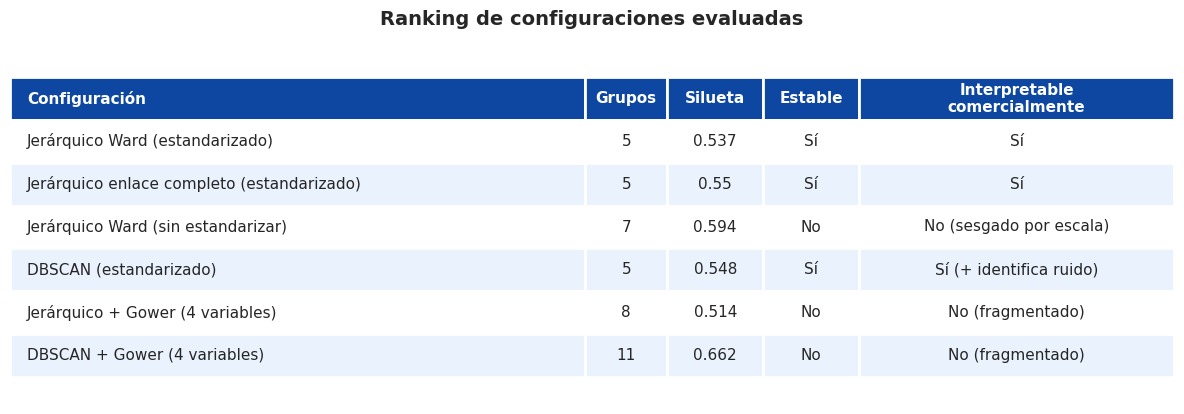

In [ ]:
ranking_config = pd.DataFrame({
    "Configuración": [
        "Jerárquico Ward (estandarizado)",
        "Jerárquico enlace completo (estandarizado)",
        "Jerárquico Ward (sin estandarizar)",
        "DBSCAN (estandarizado)",
        "Jerárquico + Gower (4 variables)",
        "DBSCAN + Gower (4 variables)"
    ],
    "Grupos": [5, 5, 7, 5, 8, 11],
    "Silueta": [0.537, 0.550, 0.594, 0.548, 0.514, 0.662],
    "Estable": ["Sí", "Sí", "No", "Sí", "No", "No"],
    "Interpretable comercialmente": [
        "Sí", "Sí", "No (sesgado por escala)", "Sí (+ identifica ruido)",
        "No (fragmentado)", "No (fragmentado)"
    ]
})
tabla_bonita(ranking_config, "Ranking de configuraciones evaluadas")

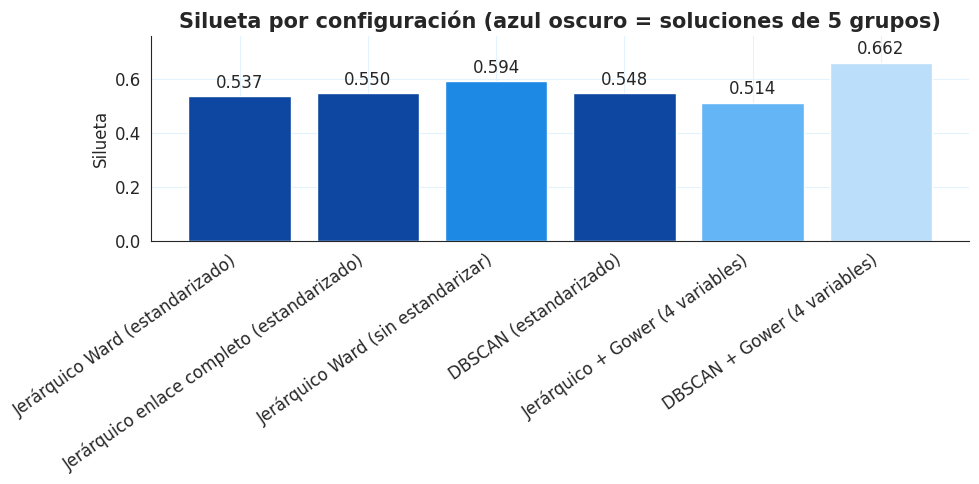

In [ ]:
# Comparación visual de silueta entre las 6 configuraciones
colores_no5 = {7: PALETA_AZUL[2], 8: PALETA_AZUL[4], 11: PALETA_AZUL[6]}
colores_barras = [AZUL_OSCURO if g == 5 else colores_no5[g] for g in ranking_config["Grupos"]]

plt.figure(figsize=(10, 5))
barras = plt.bar(ranking_config["Configuración"], ranking_config["Silueta"], color=colores_barras)
plt.bar_label(barras, fmt="%.3f", padding=3)
plt.ylim(0, ranking_config["Silueta"].max() * 1.15)
plt.title("Silueta por configuración (azul oscuro = soluciones de 5 grupos)")
plt.ylabel("Silueta")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Las tres algoritmos que coinciden en **5 grupos** (Ward estandarizado, enlace completo estandarizado y DBSCAN estandarizado) son los más estables y más interpretables. Las configuraciones con silueta más alta (Ward sin estandarizar, DBSCAN+Gower) dependen de la escala del ingreso o se dividen en microgrupos demográficos.

Se recomienda el clustering jerárquico con enlace de Ward, sobre ingreso y puntaje de gasto estandarizados, con K = 5. Se elige Ward por ser el estándar más usado y fácil de comunicar, respaldado por DBSCAN como validación.

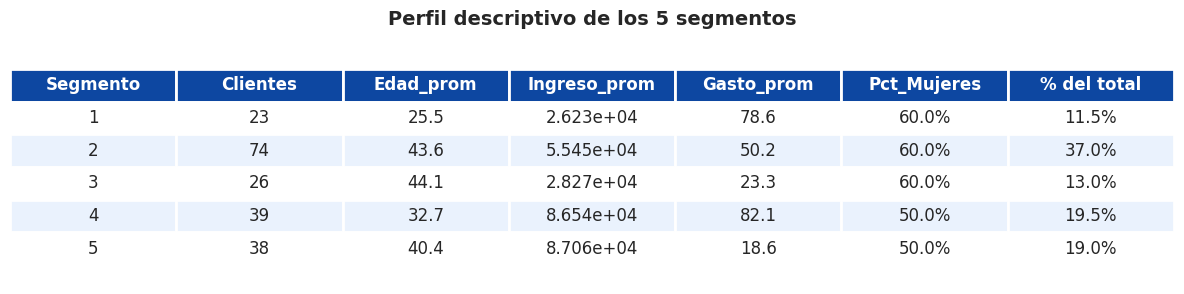

In [ ]:
# Segmentación final: Ward estandarizado, K=5
etiquetas_finales = fcluster(Z_ward_std, t=5, criterion="maxclust")
df["Segmento"] = etiquetas_finales

perfil_segmentos = (
    df.groupby("Segmento")
      .agg(
          Clientes=("Id_Cliente", "count"),
          Edad_prom=("Edad", "mean"),
          Ingreso_prom=("Ingreso", "mean"),
          Gasto_prom=("Puntaje_Gasto", "mean"),
          Pct_Mujeres=("Genero", lambda x: (x == "Mujer").mean())
      )
      .round(1)
      .reset_index()
)
perfil_segmentos["% del total"] = (perfil_segmentos["Clientes"] / len(df))
tabla_bonita(perfil_segmentos, "Perfil descriptivo de los 5 segmentos", cols_pct=["Pct_Mujeres", "% del total"])

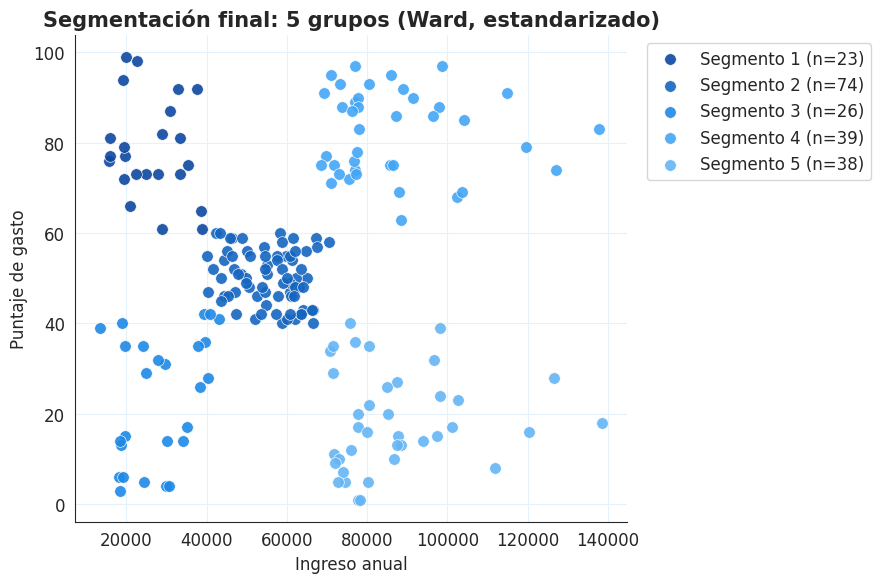

In [ ]:
# Visualización de los 5 segmentos
plt.figure(figsize=(9, 6))

nombres_segmento = {}
for seg in sorted(df["Segmento"].unique()):
    sub = df[df["Segmento"] == seg]
    plt.scatter(sub["Ingreso"], sub["Puntaje_Gasto"],
                color=PALETA_AZUL[(seg-1) % len(PALETA_AZUL)],
                edgecolor="white", linewidth=0.5, s=70, alpha=0.9,
                label=f"Segmento {seg} (n={len(sub)})")

plt.title("Segmentación final: 5 grupos (Ward, estandarizado)")
plt.xlabel("Ingreso anual")
plt.ylabel("Puntaje de gasto")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

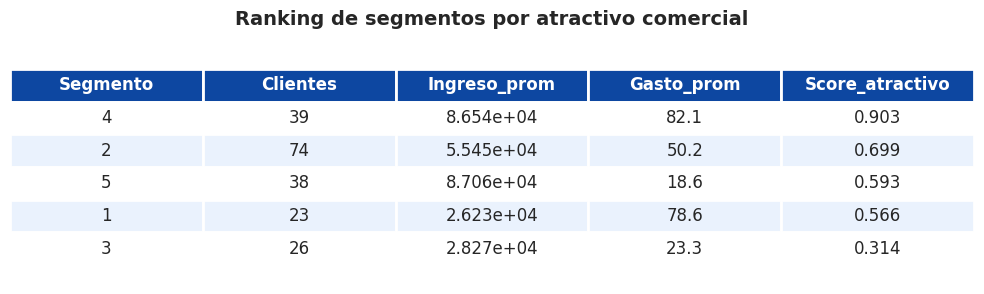

In [ ]:
# Ranking de segmentos por atractivo para la focalización
ranking_segmentos = perfil_segmentos.copy()
ranking_segmentos["Score_atractivo"] = (
    0.4 * (ranking_segmentos["Ingreso_prom"] / ranking_segmentos["Ingreso_prom"].max()) +
    0.4 * (ranking_segmentos["Gasto_prom"] / ranking_segmentos["Gasto_prom"].max()) +
    0.2 * (ranking_segmentos["Clientes"] / ranking_segmentos["Clientes"].max())
).round(3)

ranking_segmentos = ranking_segmentos.sort_values("Score_atractivo", ascending=False)
tabla_bonita(
    ranking_segmentos[["Segmento","Clientes","Ingreso_prom","Gasto_prom","Score_atractivo"]],
    "Ranking de segmentos por atractivo comercial"
)

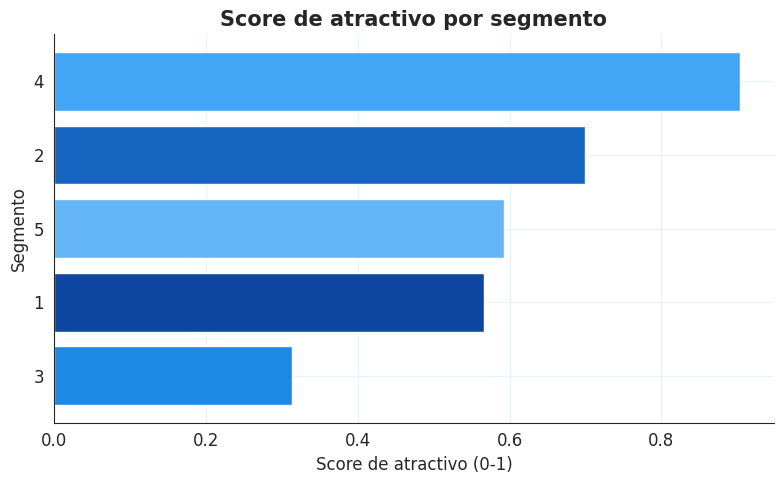

In [ ]:
# Gráfico del ranking de atractivo por segmento
plt.figure(figsize=(8, 5))
colores_seg = [PALETA_AZUL[(int(s)-1) % len(PALETA_AZUL)] for s in ranking_segmentos["Segmento"]]

plt.barh(ranking_segmentos["Segmento"].astype(str), ranking_segmentos["Score_atractivo"], color=colores_seg)
plt.gca().invert_yaxis()
plt.title("Score de atractivo por segmento")
plt.xlabel("Score de atractivo (0-1)")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()

### Recomendación final

Si segmentar, La estructura de 5 grupos aparece de forma consistente en dos algoritmos distintos (jerárquico y DBSCAN), con siluetas similares (~0,54-0,55) y sin depender de un solo método de enlace.

Se recomienda el clustering jerárquico con enlace de Ward sobre ingreso y puntaje de gasto estandarizados, K=5, validado con DBSCAN.

Los dos segmentos con mayor score de atractivo en la tabla anterior:típicamente el de ingreso alto y gasto alto (clientes ya comprometidos, listos para ofertas premium que aumenten frecuencia) y el de ingreso alto y gasto bajo (alto potencial no capturado, campaña de activación/reconquista). Ambos combinan tamaño suficiente con el mayor margen de retorno esperado por cliente.

Consideraciones y límites para la empresa:

* La segmentación se basa en un piloto de 200 clientes de una sola tienda; antes de escalar la campaña conviene validar que la estructura se mantenga en otras tiendas.

* La variable género no debe usarse como criterio de mensaje, no se encontraron diferencias significativas en comportamiento de compra.

* La variable edad sí varía significativamente entre grupos y es útil como variable descriptiva para refianr el tono del mensaje dentro de cada segmento, aunque no se usó para definir los grupos.

* DBSCAN identificó que ~11% de los clientes son "ruido", antes de excluirlos de ambas campañas conviene revisarlos caso a caso, ya que podrían responder a cualquiera de los dos mensajes.

* Cualquier tercera campaña futura (si el presupuesto crece) debería evaluarse contra este mismo ranking de atractivo, no solo por tamaño de segmento.